In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
start ='2015-01-01'

end = '2025-12-31'

stock= 'GOOG'

data=yf.download(stock,start,end)

[*********************100%***********************]  1 of 1 completed


In [3]:
data.reset_index(inplace=True)
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2015-01-02,25.939947,26.259249,25.904854,26.147542,28951268
1,2015-01-05,25.399214,25.916224,25.359179,25.863336,41196796
2,2015-01-06,24.810537,25.513148,24.765560,25.455070,57998800
3,2015-01-07,24.768026,25.071707,24.696356,25.059647,41301082
4,2015-01-08,24.846121,24.885662,24.268810,24.614307,67071641
...,...,...,...,...,...,...
2760,2025-12-23,315.268005,315.887191,310.344447,310.728954,13961400
2761,2025-12-24,315.258026,315.877212,312.911087,315.737380,6138200
2762,2025-12-26,314.548950,316.146868,313.310578,315.507719,6730900


In [4]:
ma_100_days=data.Close.rolling(100).mean()

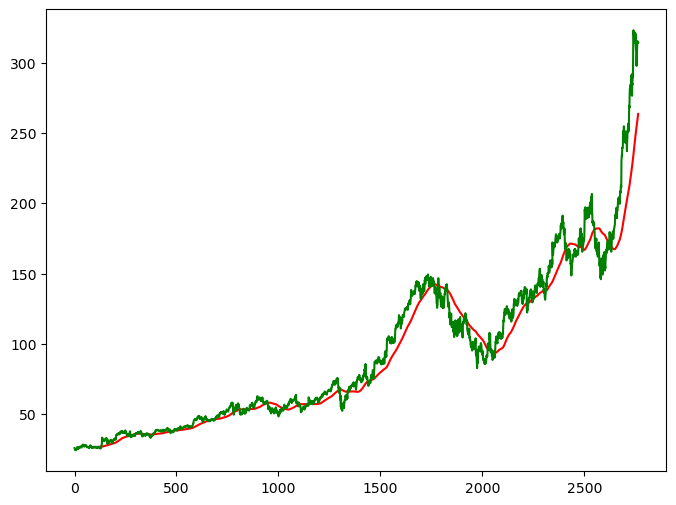

In [5]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days,'r')
plt.plot(data.Close,'g')
plt.show()

In [6]:
ma_200_days=data.Close.rolling(200).mean()


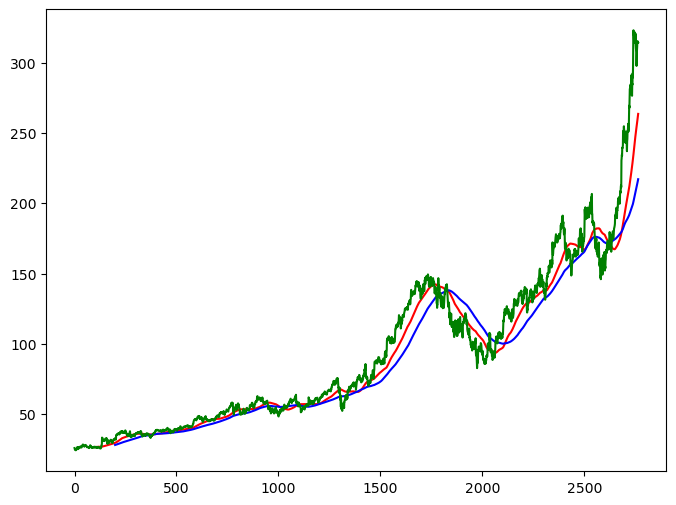

In [7]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days,'r')
plt.plot(ma_200_days,'b')
plt.plot(data.Close,'g')
plt.show()

In [8]:
data.dropna(inplace=True)

In [9]:
data_train=pd.DataFrame(data.Close[0:int(len(data)*0.80)])
data_test=pd.DataFrame(data.Close[int(len(data)*0.80):len(data)])

In [10]:
data_train.shape[0]

2212

In [11]:
data_test.shape[0]

553

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [13]:
data_train_scale=scaler.fit_transform(data_train)

In [14]:
x=[]
y=[]
for i in range (100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [15]:
x,y=np.array(x), np.array(y)

In [16]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

In [30]:
model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(x.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(100, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(100))
model.add(Dropout(0.2))

model.add(Dense(50, activation='relu'))
model.add(Dense(1))

c:\Users\Hp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [33]:
model.fit(x,y, epochs=100, batch_size=32,verbose=1)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - loss: 0.0013
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - loss: 0.0013
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - loss: 0.0011
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - loss: 0.0011
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - loss: 0.0011    
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - loss: 0.0012
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - loss: 0.0011   
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - loss: 0.0011
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - loss: 0.0011  
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - loss: 0.0010
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - loss: 8.3671e-04
Epoch 12/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - loss: 9.8701e-04
Epoch 13/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - loss: 9.5759e-04
Epoch 14/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - loss: 9.4045e-04
Epoch 15/1

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 100)       │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,105 (2.37 MB)

 Trainable params: 206,701 (807.43 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 413,404 (1.58 MB)

In [35]:
past_100_days=data_train.tail(100)

In [36]:
data_test=pd.concat([past_100_days,data_test], ignore_index=True)

In [37]:
data_test

Ticker,GOOG
0,120.576904
1,123.263222
2,124.333786
3,123.550690
4,122.291794
...,...
748,315.268005
749,315.258026
750,314.548950
751,313.979736


In [38]:
data_test_scale=scaler.transform(data_test)

In [39]:
x_test=[]
y_test=[]
for i in range (100, data_test_scale.shape[0]):
    x_test.append(data_test_scale[i-100:i])
    y_test.append(data_test_scale[i,0])
x_test,y_test=np.array(x_test), np.array(y_test)

In [40]:
y_predict=model.predict(x_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step


In [41]:
y_predict

array([[0.92647344],
       [0.8287854 ],
       [0.8194422 ],
       [0.82926977],
       [0.8242593 ],
       [0.8090897 ],
       [0.8084306 ],
       [0.81261253],
       [0.8215171 ],
       [0.83091044],
       [0.8008386 ],
       [0.79286313],
       [0.7951507 ],
       [0.8063523 ],
       [0.8087502 ],
       [0.807689  ],
       [0.8161703 ],
       [0.8071621 ],
       [0.803695  ],
       [0.787228  ],
       [0.8003832 ],
       [0.7987333 ],
       [0.7721464 ],
       [0.76446056],
       [0.77722174],
       [0.77357185],
       [0.7768844 ],
       [0.77455276],
       [0.7868696 ],
       [0.7791322 ],
       [0.7717834 ],
       [0.7502025 ],
       [0.7508352 ],
       [0.76474184],
       [0.80102044],
       [0.81271285],
       [0.8086492 ],
       [0.80171824],
       [0.79393744],
       [0.773502  ],
       [0.7745322 ],
       [0.7859873 ],
       [0.79354274],
       [0.83767754],
       [0.84598213],
       [0.865404  ],
       [0.8699427 ],
       [0.865

In [42]:
y_predict = scaler.inverse_transform(y_predict)

y_test = y_test.reshape(-1, 1)
y_test = scaler.inverse_transform(y_test)

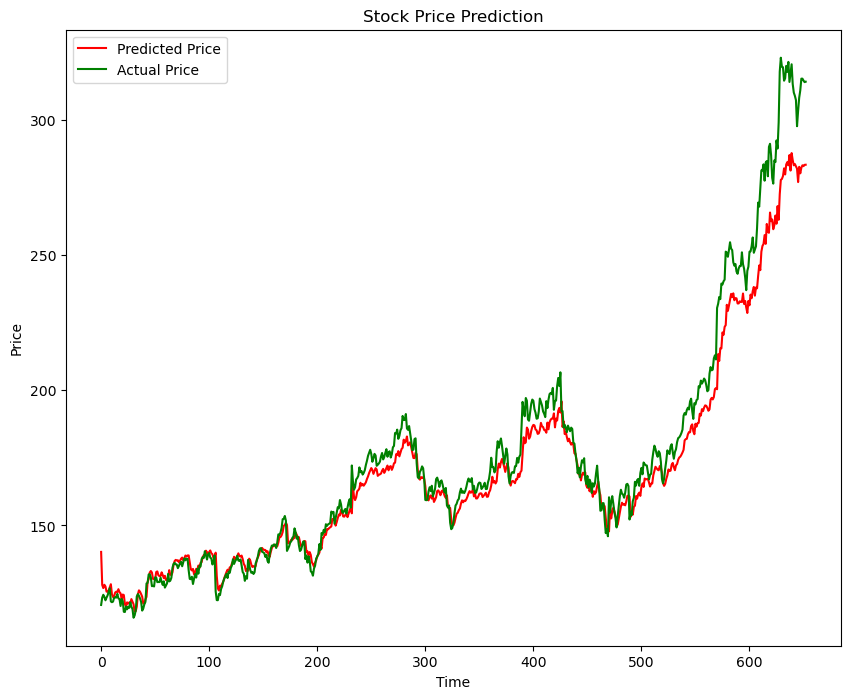

In [43]:
plt.figure(figsize=(10,8))
plt.plot(y_predict,'r', label='Predicted Price')
plt.plot(y_test,'g', label='Actual Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction')
plt.legend()
plt.show()

In [44]:
model.save('Stock Predictions Model.keras')